In [ ]:
#Qué hace: identifica y caracteriza la infección en la cohorte UCI y su distribución temporal.
#Clave: define la infección de forma operativa y descriptiva, sin inferencia.

In [1]:
# --- Descriptive analysis: infection types (microbiology-based) --------------
# This query identifies all admissions with a positive microbiology record
# and classifies them into clinically relevant pathogen groups:
#   1. Enterobacterales (E. coli, Klebsiella spp., Enterobacter spp.)
#   2. Pseudomonas aeruginosa
#   3. Acinetobacter spp.
#   4. Stenotrophomonas maltophilia
#   5. Enterococcus faecium
#   6. Staphylococcus aureus
#
# The analysis is descriptive only (no antibiotics yet).
# It counts unique patients and admissions with each pathogen group.

In [2]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [11]:
# Set your GCP project explicitly to avoid ADC surprises in notebooks.
PROJECT_ID = "mimic-pruebas"  # <-- change to your GCP project if needed

# Create a BigQuery client
client = bigquery.Client(project=PROJECT_ID)

# Base dataset/table prefixes for MIMIC-IV v3.1 on BigQuery
DERIVED = "physionet-data.mimiciv_3_1_derived"
HOSP = "physionet-data.mimiciv_3_1_hosp"
ICU  = "physionet-data.mimiciv_3_1_icu"

client = bigquery.Client(project=PROJECT_ID)

In [12]:
sql_infection_groups = f"""
WITH infected_hadm AS (
  SELECT
    a.subject_id,
    a.hadm_id,
    LOWER(TRIM(me.org_name)) AS org_name_lc,
    a.admittime,
    a.dischtime
  FROM `{HOSP}.microbiologyevents` AS me
  JOIN `{HOSP}.admissions` AS a
    ON me.hadm_id = a.hadm_id
  WHERE (
    LOWER(COALESCE(me.interpretation, '')) LIKE '%positive%'
    OR me.org_name IS NOT NULL
  )
  AND me.charttime BETWEEN a.admittime AND a.dischtime
),
grouped AS (
  SELECT
    subject_id,
    hadm_id,
    org_name_lc,
    CASE
      WHEN org_name_lc LIKE '%escherichia coli%' OR org_name_lc LIKE '%e. coli%' THEN 'Enterobacterales'
      WHEN org_name_lc LIKE '%klebsiella%' THEN 'Enterobacterales'
      WHEN org_name_lc LIKE '%enterobacter %' OR org_name_lc LIKE 'enterobacter%' THEN 'Enterobacterales'
      WHEN org_name_lc LIKE '%pseudomonas aeruginosa%' OR org_name_lc LIKE '%p. aeruginosa%' THEN 'Pseudomonas aeruginosa'
      WHEN org_name_lc LIKE '%acinetobacter%' THEN 'Acinetobacter spp.'
      WHEN org_name_lc LIKE '%stenotrophomonas maltophilia%' OR org_name_lc LIKE '%s. maltophilia%' THEN 'Stenotrophomonas maltophilia'
      WHEN org_name_lc LIKE '%enterococcus faecium%' OR org_name_lc LIKE '%e. faecium%' THEN 'Enterococcus faecium'
      WHEN org_name_lc LIKE '%staphylococcus aureus%' OR org_name_lc LIKE '%s. aureus%' THEN 'Staphylococcus aureus'
      ELSE 'Other pathogens'
    END AS pathogen_group
  FROM infected_hadm
)
SELECT
  pathogen_group,
  COUNT(DISTINCT subject_id) AS n_patients,
  COUNT(DISTINCT hadm_id) AS n_admissions
FROM grouped
GROUP BY pathogen_group
ORDER BY n_patients DESC;
"""

df_infections = client.query(sql_infection_groups).result().to_dataframe()

print("Number of admissions by pathogen group:")
display(df_infections)

E0000 00:00:1769592620.579412  947665 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


Number of admissions by pathogen group:


,pathogen_group,n_patients,n_admissions
0,Other pathogens,38050,53650
1,Enterobacterales,12267,14466
2,Pseudomonas aeruginosa,3456,4393
3,Enterococcus faecium,1131,1232
4,Stenotrophomonas maltophilia,675,757
5,Acinetobacter spp.,384,416
6,Staphylococcus aureus,116,116


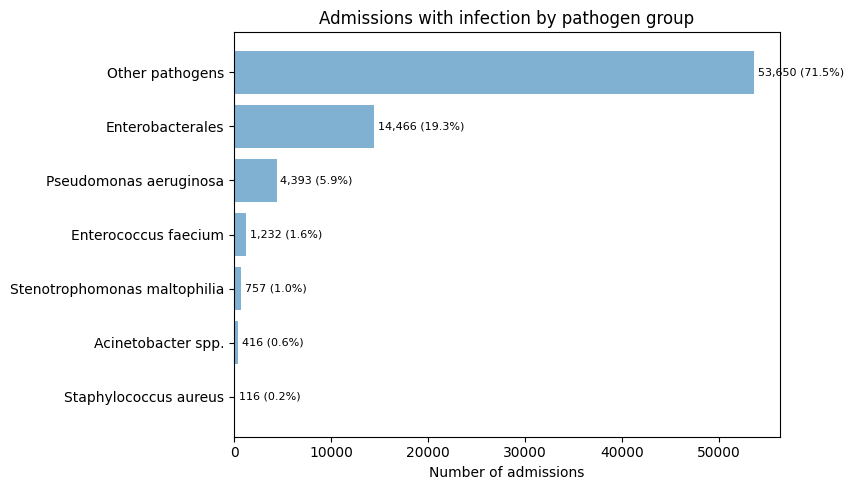

In [13]:
# --- Plot infection counts ---------------------------------------------------

df_plot = df_infections.sort_values("n_admissions", ascending=True)

plt.figure(figsize=(8,5))
bars = plt.barh(df_plot["pathogen_group"], df_plot["n_admissions"], color="#80b1d3")
plt.title("Admissions with infection by pathogen group", fontsize=12)
plt.xlabel("Number of admissions")
plt.tight_layout()

# Add counts and percentages on bars
total = df_plot["n_admissions"].sum()
for bar, value in zip(bars, df_plot["n_admissions"]):
    pct = 100 * value / total
    plt.text(value + total*0.005, bar.get_y() + bar.get_height()/2,
             f"{value:,} ({pct:.1f}%)",
             va='center', fontsize=8)

plt.show()

In [14]:
# NOTE:
# The analysis below focuses only on microbiology-confirmed infections.
# Pathogen grouping is based on text-matching of `org_name` in MIMIC-IV v3.1.
# No antibiotic information is used at this stage.
# The results describe the distribution of infections among hospitalized patients.
# To include non-ICU hospitalizations or antibiotic exposures, see subsequent steps.

In [15]:
# --- Cross infections with ICU admissions -----------------------------------
# Objective:
#   Identify the number of infected admissions (by pathogen group)
#   that required ICU care at any point during the hospital stay.
#
# Data sources:
#   - Microbiology: physionet-data.mimiciv_3_1_hosp.microbiologyevents
#   - Admissions:   physionet-data.mimiciv_3_1_hosp.admissions
#   - ICU stays:    physionet-data.mimiciv_3_1_icu.icustays
#
# Result: counts of unique patients and admissions by pathogen group and ICU status.

In [16]:
sql_infection_icu = f"""
WITH infected_hadm AS (
  SELECT
    a.subject_id,
    a.hadm_id,
    LOWER(TRIM(me.org_name)) AS org_name_lc,
    a.admittime,
    a.dischtime
  FROM `{HOSP}.microbiologyevents` AS me
  JOIN `{HOSP}.admissions` AS a
    ON me.hadm_id = a.hadm_id
  WHERE (
    LOWER(COALESCE(me.interpretation, '')) LIKE '%positive%'
    OR me.org_name IS NOT NULL
  )
  AND me.charttime BETWEEN a.admittime AND a.dischtime
),
grouped AS (
  SELECT
    subject_id,
    hadm_id,
    CASE
      WHEN org_name_lc LIKE '%escherichia coli%' OR org_name_lc LIKE '%e. coli%' THEN 'Enterobacterales'
      WHEN org_name_lc LIKE '%klebsiella%' THEN 'Enterobacterales'
      WHEN org_name_lc LIKE '%enterobacter %' OR org_name_lc LIKE 'enterobacter%' THEN 'Enterobacterales'
      WHEN org_name_lc LIKE '%pseudomonas aeruginosa%' OR org_name_lc LIKE '%p. aeruginosa%' THEN 'Pseudomonas aeruginosa'
      WHEN org_name_lc LIKE '%acinetobacter%' THEN 'Acinetobacter spp.'
      WHEN org_name_lc LIKE '%stenotrophomonas maltophilia%' OR org_name_lc LIKE '%s. maltophilia%' THEN 'Stenotrophomonas maltophilia'
      WHEN org_name_lc LIKE '%enterococcus faecium%' OR org_name_lc LIKE '%e. faecium%' THEN 'Enterococcus faecium'
      WHEN org_name_lc LIKE '%staphylococcus aureus%' OR org_name_lc LIKE '%s. aureus%' THEN 'Staphylococcus aureus'
      ELSE 'Other pathogens'
    END AS pathogen_group
  FROM infected_hadm
),
icu_adm AS (
  SELECT DISTINCT hadm_id
  FROM `{ICU}.icustays`
)
SELECT
  g.pathogen_group,
  CASE WHEN i.hadm_id IS NOT NULL THEN 'ICU' ELSE 'No ICU' END AS icu_status,
  COUNT(DISTINCT g.hadm_id) AS n_admissions,
  COUNT(DISTINCT g.subject_id) AS n_patients
FROM grouped AS g
LEFT JOIN icu_adm AS i
  ON g.hadm_id = i.hadm_id
GROUP BY pathogen_group, icu_status
ORDER BY pathogen_group, icu_status;
"""

df_infection_icu = client.query(sql_infection_icu).result().to_dataframe()
display(df_infection_icu)

E0000 00:00:1769592627.344970  947665 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


,pathogen_group,icu_status,n_admissions,n_patients
0,Acinetobacter spp.,ICU,275,252
1,Acinetobacter spp.,No ICU,141,134
2,Enterobacterales,ICU,6476,6014
3,Enterobacterales,No ICU,7990,6911
4,Enterococcus faecium,ICU,693,667
5,Enterococcus faecium,No ICU,539,499
6,Other pathogens,ICU,22906,19550
7,Other pathogens,No ICU,30744,22419
8,Pseudomonas aeruginosa,ICU,2142,1841
9,Pseudomonas aeruginosa,No ICU,2251,1812


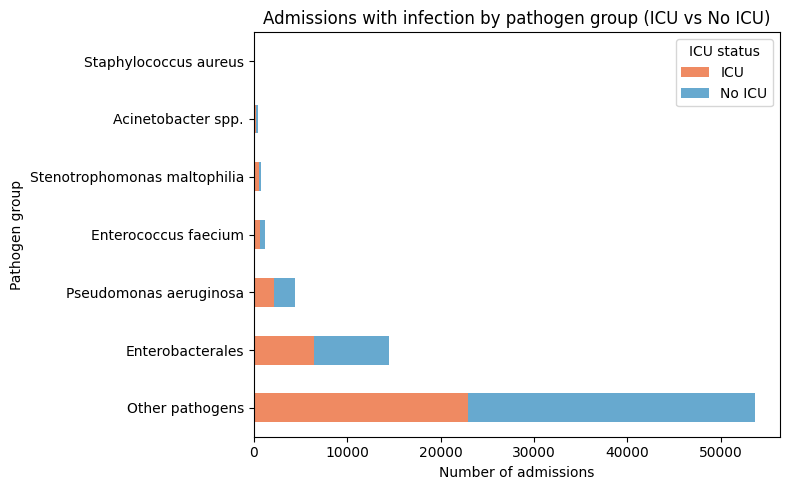

In [17]:
# --- Stacked bar chart: infections by ICU vs No ICU -------------------------
pivot = df_infection_icu.pivot(
    index="pathogen_group", columns="icu_status", values="n_admissions"
).fillna(0)

pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]  # sort by total

pivot.plot(
    kind="barh",
    stacked=True,
    figsize=(8,5),
    color=["#ef8a62", "#67a9cf"]
)
plt.title("Admissions with infection by pathogen group (ICU vs No ICU)")
plt.xlabel("Number of admissions")
plt.ylabel("Pathogen group")
plt.legend(title="ICU status")
plt.tight_layout()
plt.show()

In [18]:
# --- ICU proportions per pathogen group -------------------------------------
summary = (
    df_infection_icu.pivot(index="pathogen_group", columns="icu_status", values="n_admissions")
    .fillna(0)
    .assign(total=lambda x: x.sum(axis=1))
)
summary["ICU_rate"] = summary["ICU"] / summary["total"]
summary = summary.sort_values("ICU_rate", ascending=False)
display(summary)

icu_status,ICU,No ICU,total,ICU_rate
pathogen_group,,,,
Staphylococcus aureus,100,16,116,0.862069
Stenotrophomonas maltophilia,529,228,757,0.698811
Acinetobacter spp.,275,141,416,0.661058
Enterococcus faecium,693,539,1232,0.5625
Pseudomonas aeruginosa,2142,2251,4393,0.487594
Enterobacterales,6476,7990,14466,0.44767
Other pathogens,22906,30744,53650,0.426952


In [19]:
# NOTE:
# This analysis quantifies how many microbiology-confirmed infections required ICU care.
# Each admission is counted once per pathogen group.
# Because `mimiciv_hosp.microbiologyevents` includes all hospital samples,
# an admission may appear in multiple pathogen groups if several organisms were identified.